# Worksheet 7 - Neural networks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_absolute_error, r2_score

## 1 - Data

In [2]:
spectra = np.load('spectra.npy')
labels = pd.read_csv('labels_table.csv', index_col=0) # after visual insepction the table showed an unnamed index column --> index_col=0
auxillary = pd.read_csv('auxillary_table.csv')

In [3]:
labels

,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...
41418,train41419,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,train41420,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,train41421,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,train41422,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


In [4]:
auxillary

,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity
0,train1,530.7650,1.968526e+30,6.678720e+08,5636.0,3.990923e+26,9.668577,0.088530,16.642039
1,train2,440.0890,1.948642e+30,7.235280e+08,5449.0,4.977001e+26,4.218028,0.050752,5.197135
2,train3,1126.3700,2.147483e+30,7.791840e+08,5675.0,9.686804e+25,2.828042,0.040158,7.871718
3,train4,1257.1600,2.048062e+30,7.374420e+08,5849.0,4.486340e+25,3.855604,0.048601,4.894681
4,train5,211.5530,2.525281e+30,1.092249e+09,6200.0,2.416329e+26,3.076340,0.044833,5.870151
...,...,...,...,...,...,...,...,...,...
41418,train41419,703.3020,1.988410e+30,7.722270e+08,5821.0,7.125924e+26,5.370647,0.060024,4.544766
41419,train41420,72.7998,1.292466e+30,4.035060e+08,4258.0,7.709155e+25,6.342000,0.058089,13.050003
41420,train41421,1786.4800,1.789569e+30,7.096140e+08,6002.0,2.794853e+25,3.546511,0.043946,19.728779
41421,train41422,329.0410,1.849221e+30,6.748290e+08,5519.0,1.400242e+26,22.631964,0.152856,3.649544


In [5]:
# Logarithmic transformation of auxillary columns

aux = pd.DataFrame({
    'log_star_distance': np.log10(auxillary['star_distance']),
    'log_star_mass':     np.log10(auxillary['star_mass_kg']),
    'log_star_radius':   np.log10(auxillary['star_radius_m']),
    'star_temperature':  auxillary['star_temperature'], # no logarithm for temperature
    'log_planet_mass':   np.log10(auxillary['planet_mass_kg']),
    'log_orbital_period':np.log10(auxillary['planet_orbital_period']),
    'log_planet_dist':   np.log10(auxillary['planet_distance']),
    'log_surface_grav':  np.log10(auxillary['planet_surface_gravity']),
}).to_numpy()

## 2 - Data visualisation and pre-processing

**Plot a few example spectra and the mean and standard deviation of all spectra:**

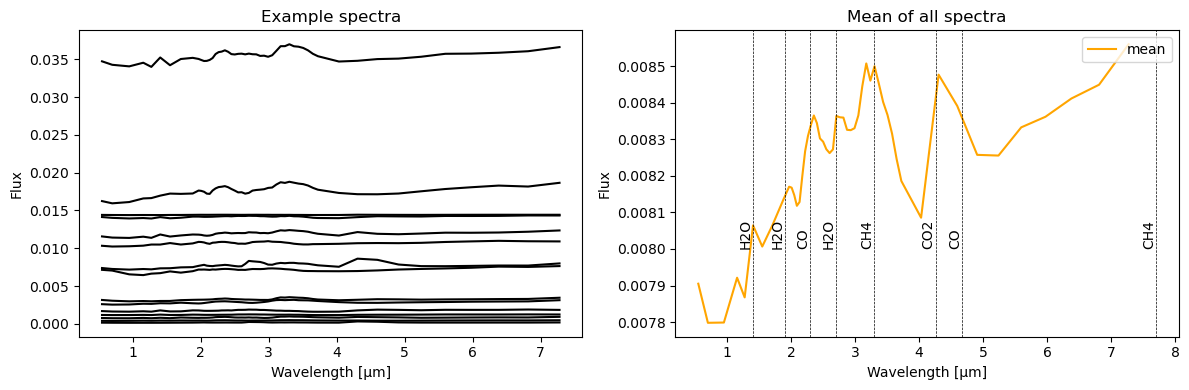

In [6]:
random = np.random.randint(0, 41423, size=15)
mean_spectrum = spectra[:, :, 1].mean(axis=0)

emission_lines = {
    'H2O': [1.4, 1.9, 2.7],
    'CO2': [4.26],
    'CO': [2.3, 4.67],
    'CH4': [3.3, 7.7],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for i in random:
    ax1.plot(spectra[i,:,0], spectra[i, :, 1], color='black')

ax1.set_xlabel('Wavelength [μm]')
ax1.set_ylabel('Flux')
ax1.set_title('Example spectra')

ax2.plot(spectra[0,:,0], mean_spectrum, color='orange', label='mean')
ax2.set_xlabel('Wavelength [μm]')
ax2.set_ylabel('Flux')
ax2.set_title('Mean of all spectra')

for molecule, wavelengths in emission_lines.items():
    for w in wavelengths:
        ax2.axvline(x=w, linewidth=0.5, color='black', linestyle='--')
        ax2.text(w, 0.008, molecule, rotation=90, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

## 3 - Neural Network Model

**Combine X with auxillary data:**

In [7]:
X_full = np.concatenate([spectra[:,:,1], aux], axis=1)

**Split data into training, validation and test data (70/15/15):**

The spectra are the input data X, the labels (so the planets properties) are the targets y. The auxillary data are additional inputs that should lead to better predictions and are now included in X.

In [8]:
# split 80/20
X_train, X_temp, y_train, y_temp = train_test_split(X_full, labels, test_size=0.20, random_state=42)

# split again into test and validation sample (10/10)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(33138, 60)
(4142, 60)
(4143, 60)


**Prepare the data:**

Convert the labels into a numpy array. Also, scale all the data to reach better results from the model (in order to do this, the data has to be flattened first, because the StandardScaler() expects a 2D array.)

In [9]:
# Keep only the target columns, exclude indices and IDs and convert to numpy array

y_train = y_train.select_dtypes(include=['float64', 'int64']).to_numpy()
y_val = y_val.select_dtypes(include=['float64', 'int64']).to_numpy()
y_test = y_test.select_dtypes(include=['float64', 'int64']).to_numpy()

In [10]:
# Flatten X data

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)


# Scale the data

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_val   = X_scaler.transform(X_val)
X_test  = X_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)


**Fit a feed forward neural network model to the training and validation data:**

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])

])

c:\Users\helen\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile the model:**

In [12]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

**Train the model:**

In [13]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=300, batch_size=128)

Epoch 1/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7478 - mae: 0.6694 - val_loss: 0.7097 - val_mae: 0.6432
Epoch 2/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6975 - mae: 0.6340 - val_loss: 0.6842 - val_mae: 0.6266
Epoch 3/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6686 - mae: 0.6167 - val_loss: 0.6499 - val_mae: 0.6065
Epoch 4/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6407 - mae: 0.5998 - val_loss: 0.6293 - val_mae: 0.5939
Epoch 5/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6175 - mae: 0.5847 - val_loss: 0.6080 - val_mae: 0.5786
Epoch 6/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5993 - mae: 0.5736 - val_loss: 0.5828 - val_mae: 0.5647
Epoch 7/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5761 - mae: 0.5595 - val_loss: 0.5566 - val_mae: 0.5493
Epoch 8/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5564 - mae: 0.5479 - val_loss: 0.5370 - val_mae: 0.5348
Epoch 9/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

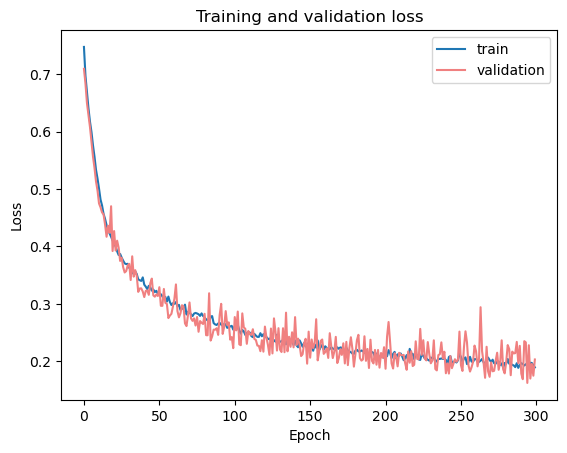

In [14]:
# Plot training and validation loss

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation', color='lightcoral')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

**Predict the test data:**

In [15]:
y_pred = model.predict(X_test)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step


**Scale values back:**

In [16]:
y_pred = y_scaler.inverse_transform(y_pred)
y_true = y_scaler.inverse_transform(y_test)

**Evaluate model:**

In [17]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - loss: 0.2066 - mae: 0.2863
Test loss: 0.20656143128871918
Test MAE: 0.2862565219402313


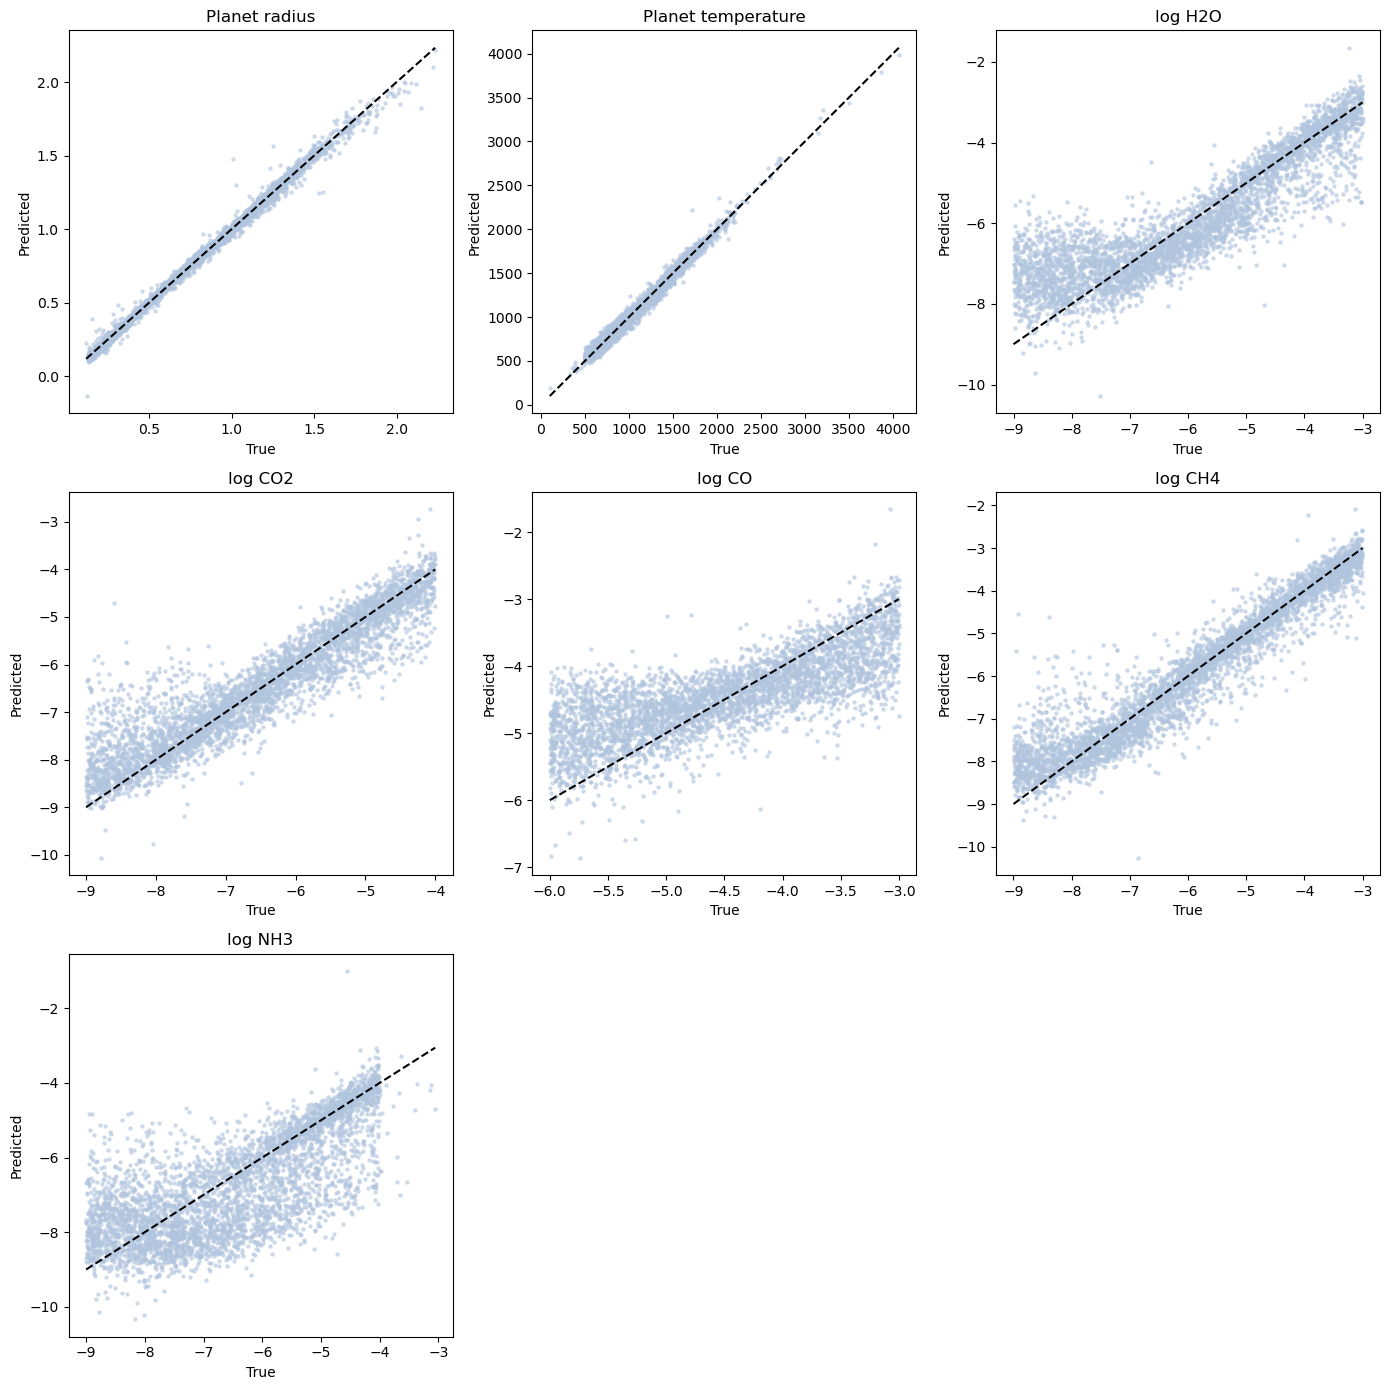

In [ ]:
target_names = [
    'Planet radius',
    'Planet temperature',
    'log H2O',
    'log CO2',
    'log CO',
    'log CH4',
    'log NH3'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, name in enumerate(target_names):

    axes[i].scatter(y_true[:, i], y_pred[:, i], alpha=0.5, s=5, color='lightsteelblue')

    axes[i].plot(
        [y_true[:, i].min(), y_true[:, i].max()],
        [y_true[:, i].min(), y_true[:, i].max()],
        color='black',
        linestyle='--'
    )

    axes[i].set_xlabel('True')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(name)

# Hide unused subplots
for j in range(len(target_names), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()